### [피자 배달시간 예측 - 회귀 (Regression)]

In [1]:
## 데이터 관련
import pandas as pd
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt, koreanize_matplotlib
import seaborn as sns

## ML 관련
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib, os

In [2]:
# 데이터 로드
df = pd.read_csv('../Data/Numbers/pizza_delivery_time.csv')

print(f'shape : {df.shape}')
print(f'\n결측치 : {df.isnull().sum().sum()}개')
print(f'\n타겟(Delivery_Time_min) 통계')
print(df['Delivery_Time_min'].describe())

df.head()

shape : (120, 9)

결측치 : 0개

타겟(Delivery_Time_min) 통계
count    120.000000
mean      54.834167
std       12.890049
min       30.000000
25%       47.275000
50%       54.950000
75%       63.400000
max       88.500000
Name: Delivery_Time_min, dtype: float64


,OrderID,Distance_km,Pizza_Count,Traffic_Score,Rain,Weekend,Temperature_C,Prep_Time_min,Delivery_Time_min
0,PZ0001,4.06,2,4,0,0,24.0,10.0,56.7
1,PZ0002,9.53,4,4,0,1,17.5,13.7,77.2
2,PZ0003,7.45,1,3,1,0,31.3,8.4,60.8
3,PZ0004,6.19,6,1,0,0,22.7,15.9,57.8
4,PZ0005,1.98,1,3,0,0,29.1,10.6,37.5


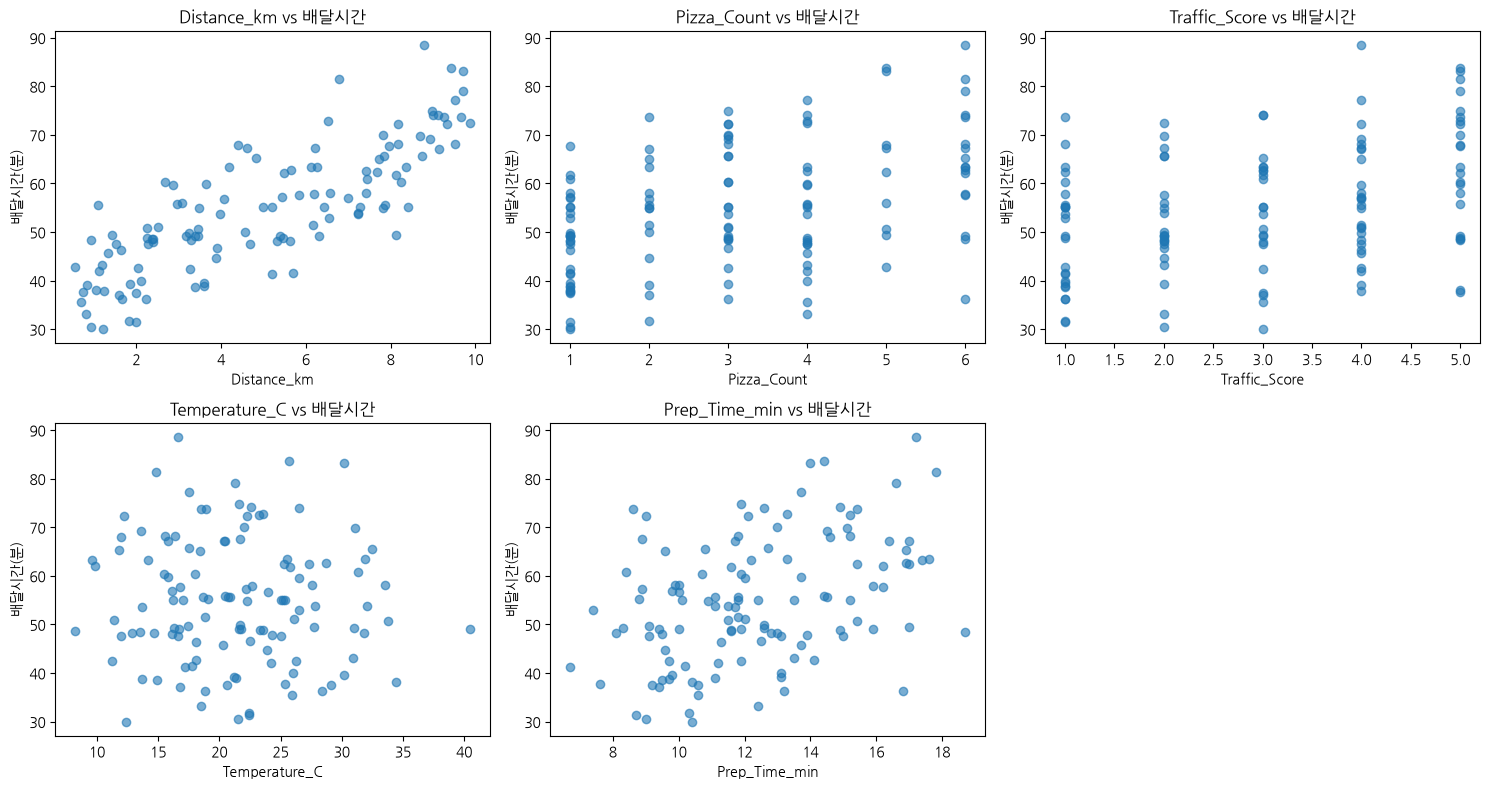

Delivery_Time_min    1.000000
Distance_km          0.810669
Pizza_Count          0.432568
Prep_Time_min        0.405158
Traffic_Score        0.360970
Rain                 0.192428
Weekend              0.068877
Temperature_C       -0.049483
Name: Delivery_Time_min, dtype: float64


In [3]:
# 피처별 배달시간 상관관계 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Distance_km', 'Pizza_Count', 'Traffic_Score', 'Temperature_C', 'Prep_Time_min']

for ax, col in zip(axes.flat, num_cols):
    ax.scatter(df[col], df['Delivery_Time_min'], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel('배달시간(분)')
    ax.set_title(f'{col} vs 배달시간')

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

# 상관계수 확인
print(df.drop('OrderID', axis=1).corr()['Delivery_Time_min'].sort_values(ascending=False))

In [4]:
# 피처 / 타겟 분리 + train/test 분리

# OrderID는 식별자 → 학습에 불필요하므로 제거
feature = df.drop(['OrderID', 'Delivery_Time_min'], axis=1)
target  = df['Delivery_Time_min']

print(f'피처 : {feature.columns.tolist()}')
print(f'타겟 : Delivery_Time_min  (평균 {target.mean():.1f}분, 범위 {target.min():.0f}~{target.max():.0f}분)')

# 회귀는 stratify 없음 (클래스 비율 개념 없음)
x_train, x_test, y_train, y_test = train_test_split(
    feature, target,
    test_size=0.2,
    random_state=42
)
print(f'\nx_train: {x_train.shape}, x_test: {x_test.shape}')

피처 : ['Distance_km', 'Pizza_Count', 'Traffic_Score', 'Rain', 'Weekend', 'Temperature_C', 'Prep_Time_min']
타겟 : Delivery_Time_min  (평균 54.8분, 범위 30~88분)

x_train: (96, 7), x_test: (24, 7)


In [5]:
# Pipeline + GridSearchCV

pipe = Pipeline(steps=[
    ('scaler',  StandardScaler()),
    ('dtModel', DecisionTreeRegressor(random_state=42))
])

param_dict = {
    'dtModel__max_depth':        [3, 5, 7, 10, None],
    'dtModel__min_samples_leaf': [1, 2, 5, 10],
    'dtModel__criterion':        ['squared_error', 'absolute_error']
}

# 회귀 교차검증 → KFold (StratifiedKFold 아님)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(pipe, param_grid=param_dict, cv=kf,
                  scoring='neg_root_mean_squared_error',   # RMSE 기준으로 최적화
                  return_train_score=True, n_jobs=-1)
gs.fit(x_train, y_train)

best_model = gs.best_estimator_
print(f'최적 파라미터     : {gs.best_params_}')
print(f'최고 CV RMSE     : {-gs.best_score_:.4f} 분')

최적 파라미터     : {'dtModel__criterion': 'squared_error', 'dtModel__max_depth': 5, 'dtModel__min_samples_leaf': 5}
최고 CV RMSE     : 6.7022 분


RMSE : 6.4774 분   (예측 오차 평균 ±6.5분)
MAE  : 5.2709 분
R²   : 0.7731       (1에 가까울수록 좋음)

Train Score (R²) : 0.8885
Test  Score (R²) : 0.7731


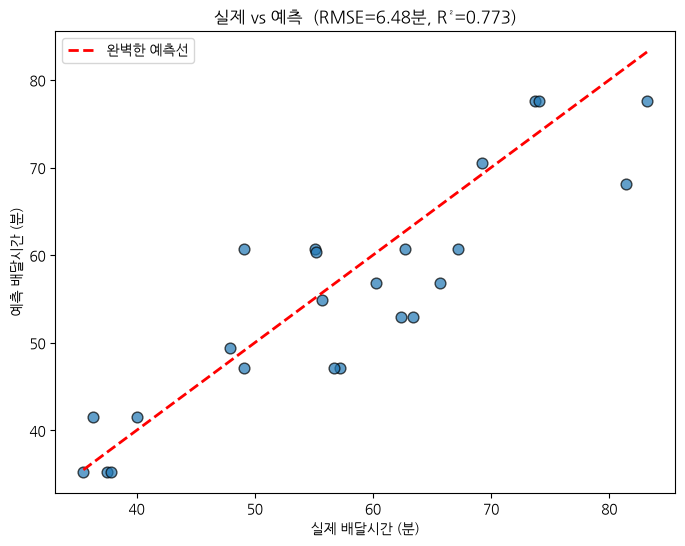

In [6]:
# 성능 평가

y_pred = best_model.predict(x_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:.4f} 분   (예측 오차 평균 ±{rmse:.1f}분)')
print(f'MAE  : {mae:.4f} 분')
print(f'R²   : {r2:.4f}       (1에 가까울수록 좋음)')
print(f'\nTrain Score (R²) : {best_model.score(x_train, y_train):.4f}')
print(f'Test  Score (R²) : {best_model.score(x_test,  y_test):.4f}')

# 실제 vs 예측 비교 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='완벽한 예측선')
plt.xlabel('실제 배달시간 (분)')
plt.ylabel('예측 배달시간 (분)')
plt.title(f'실제 vs 예측  (RMSE={rmse:.2f}분, R²={r2:.3f})')
plt.legend()
plt.show()

In [7]:
# 모델 저장 / 새 주문 예측

os.makedirs('../Models', exist_ok=True)
joblib.dump(best_model, '../Data/Models/pizza_model.pkl')
print(f'저장')

# 새 주문 예측 (거리 5km, 피자 2판, 교통점수 3, 비X, 주말O, 기온 22도, 준비시간 12분)
new_order = pd.DataFrame([[5.0, 2, 3, 0, 1, 22.0, 12.0]],
                         columns=feature.columns)

pred_time = best_model.predict(new_order)[0]
print(f'\n새 주문 예측 배달시간 : {pred_time:.1f} 분')

저장

새 주문 예측 배달시간 : 50.5 분
